# Streaming cohort figures

Restyled cohort-selection figures for the streaming-report thesis chapter. Loads only
already-computed artifacts from `Data/enriched_multimodal/` (`cohort.csv`, `segments.csv`,
`segment_stats.csv`, `sensitivity_duration.csv`, `cohort_selection_metadata.json`) written
by `Preprocessing/cohort_selection.py`. This notebook does not rerun ingestion, Stage 1, or
Stage 2 of that pipeline, and does not change the retained cohort in any way; it only
re-derives a scoreable-anchor count from `segment_stats.csv` and re-renders sensitivity
figures around that new count.

`sweep_results.csv` is intentionally not reopened: its `score` column was built from
`n_valid_windows`, and the joint sensitivity heatmap below rebuilds that grid from scratch
using the scoreable-anchor definition instead.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid", {"axes.edgecolor": "0.3", "grid.color": "0.85"})

DATA_DIR   = Path("/home/myriamcharfeddine/CGM/Data/enriched_multimodal")
FIGURE_DIR = Path("/home/myriamcharfeddine/CGM/SSM-CGM/figures/generated")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Same palette/order as the project's other figure scripts
# (e.g. static_phenotype_trajectory_phase3_figures.py, within_subtype_config.py)
GLYCEMIC_STRATA = ["normoglycemia", "prediabetes", "T2D-oral", "T2D-insulin"]
ALL_STRATA      = GLYCEMIC_STRATA + ["unclassified"]
STRATUM_COLORS  = ["#BA2828", "#003366", "#5BBABA", "#FF0000", "#888888"]
STRATUM_COLOR_MAP = dict(zip(ALL_STRATA, STRATUM_COLORS))

FIGURE_DPI = 150


In [2]:
# Load only the already-computed artifacts named in the task -- no raw ingestion,
# no Stage 1 rerun, and sweep_results.csv is deliberately not reopened.
cohort_df   = pd.read_csv(DATA_DIR / "cohort.csv")
segments_df = pd.read_csv(DATA_DIR / "segments.csv")
seg_stats   = pd.read_csv(DATA_DIR / "segment_stats.csv")
sens_dur_df = pd.read_csv(DATA_DIR / "sensitivity_duration.csv")
with open(DATA_DIR / "cohort_selection_metadata.json") as f:
    meta_json = json.load(f)

MIN_DURATION_H = meta_json["config"]["min_duration_h"]  # 108h, same floor cohort_selection.py used

RETAINED_PARTICIPANT_IDS = set(cohort_df["participant_id"].astype(str))
RETAINED_N = len(RETAINED_PARTICIPANT_IDS)

print("Loaded from:", DATA_DIR)
print(f"  cohort.csv                   : {len(cohort_df)} rows")
print(f"  segments.csv                 : {len(segments_df)} rows")
print(f"  segment_stats.csv            : {len(seg_stats)} rows")
print(f"  sensitivity_duration.csv     : {len(sens_dur_df)} rows")
print(f"  cohort_selection_metadata.json: {len(meta_json)} top-level keys")
print(f"\nRetained cohort per cohort.csv: {RETAINED_N} participants")
assert RETAINED_N == 1591, f"Expected the final retained cohort of 1,591 participants, found {RETAINED_N}"


Loaded from: /home/myriamcharfeddine/CGM/Data/enriched_multimodal
  cohort.csv                   : 1591 rows
  segments.csv                 : 2619 rows
  segment_stats.csv            : 2619 rows
  sensitivity_duration.csv     : 29 rows
  cohort_selection_metadata.json: 6 top-level keys

Retained cohort per cohort.csv: 1591 participants


## Scoreable-anchor definition

Replaces "valid window" everywhere below it is used. A scoreable anchor is a context-start
position at which a full context block, immediately followed by the forecast target, fits
inside a segment -- counted as a closed-form function of segment length alone, evaluated on
`segment_stats.csv`'s `n_bins` column.

In [3]:
CONTEXT_BINS = 72   # 6 hours at 5-minute resolution: the actual truncated-BPTT training
                    # chunk length, and the smallest nonzero value in the personalization
                    # warm-up sweep {0, 6, 12, 24, 48} hours
TARGET_BINS  = 12   # 1-hour forecast horizon, H=12 steps, matching the model's real
                    # forecast horizon
STRIDE_BINS  = 3    # 15-minute anchor stride, matching the real training/validation/
                    # evaluation anchor cadence (anchor_stride_minutes: 15 in the training
                    # config)

print("Scoreable-anchor definition:")
print(f"  CONTEXT_BINS = {CONTEXT_BINS}  ({CONTEXT_BINS * 5 / 60:.0f}h context)")
print(f"  TARGET_BINS  = {TARGET_BINS}  ({TARGET_BINS * 5 / 60:.0f}h forecast horizon)")
print(f"  STRIDE_BINS  = {STRIDE_BINS}  ({STRIDE_BINS * 5}min anchor stride)")
print("  n_scoreable_anchors(n_bins) = max(0, (n_bins - CONTEXT_BINS - TARGET_BINS) // STRIDE_BINS + 1)")


def n_scoreable_anchors(n_bins):
    """Vectorized closed-form scoreable-anchor count from segment length in bins."""
    n_bins = np.asarray(n_bins)
    return np.maximum(0, (n_bins - CONTEXT_BINS - TARGET_BINS) // STRIDE_BINS + 1)


Scoreable-anchor definition:
  CONTEXT_BINS = 72  (6h context)
  TARGET_BINS  = 12  (1h forecast horizon)
  STRIDE_BINS  = 3  (15min anchor stride)
  n_scoreable_anchors(n_bins) = max(0, (n_bins - CONTEXT_BINS - TARGET_BINS) // STRIDE_BINS + 1)


In [4]:
seg_stats = seg_stats.copy()
seg_stats["scoreable_anchors"] = n_scoreable_anchors(seg_stats["n_bins"].values)

per_participant_anchors = (
    seg_stats.groupby("participant_id")["scoreable_anchors"]
    .sum()
    .rename("total_scoreable_anchors")
)

cohort_df = cohort_df.merge(
    per_participant_anchors, left_on="participant_id", right_index=True, how="left"
)
assert cohort_df["total_scoreable_anchors"].isna().sum() == 0, \
    "Every retained participant must have at least one segment in segment_stats.csv"
cohort_df["total_scoreable_anchors"] = cohort_df["total_scoreable_anchors"].astype(int)

anchor_dist = cohort_df["total_scoreable_anchors"]
percentiles = [0, 5, 10, 25, 50, 75, 90, 95, 100]
pct_values  = np.percentile(anchor_dist, percentiles)

print(f"total_scoreable_anchors distribution across {len(cohort_df)} retained participants:")
print(f"  min    : {anchor_dist.min():,}")
print(f"  median : {anchor_dist.median():,.0f}")
print(f"  max    : {anchor_dist.max():,}")
print("  percentiles:")
for p, v in zip(percentiles, pct_values):
    print(f"    p{p:<3d}: {v:,.0f}")


total_scoreable_anchors distribution across 1591 retained participants:
  min    : 169
  median : 675
  max    : 925
  percentiles:
    p0  : 169
    p5  : 238
    p10 : 318
    p25 : 501
    p50 : 675
    p75 : 814
    p90 : 852
    p95 : 862
    p100: 925


## Figure: cohort attrition funnel

Same four stages, same source counts (`cohort_selection_metadata.json["counts"]`), as the
existing funnel figure, restyled to the current palette.

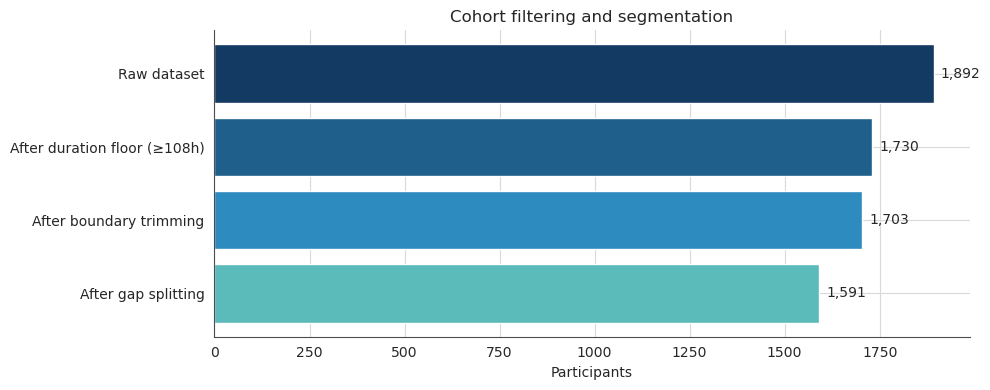

Saved: /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/cohort_attrition_funnel.png
Source: cohort_selection_metadata.json['counts']
Columns/keys used: raw, after_duration_floor, after_trim, after_segmentation
Retained cohort check: funnel's final stage (1,591) matches cohort.csv row count (1,591): True


In [5]:
FUNNEL_COLORS = ["#123A63", "#1F5F8B", "#2E8BC0", "#5BBABA"]

counts = meta_json["counts"]
funnel_labels = [
    "Raw dataset",
    f"After duration floor (\u2265{MIN_DURATION_H:.0f}h)",
    "After boundary trimming",
    "After gap splitting",
]
funnel_values = [
    counts["raw"],
    counts["after_duration_floor"],
    counts["after_trim"],
    counts["after_segmentation"],
]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(funnel_labels[::-1], funnel_values[::-1], color=FUNNEL_COLORS[::-1])
for bar, val in zip(bars, funnel_values[::-1]):
    ax.text(bar.get_width() + max(funnel_values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10)
ax.set_xlabel("Participants")
ax.set_title("Cohort filtering and segmentation")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = FIGURE_DIR / "cohort_attrition_funnel.png"
fig.savefig(out_path, dpi=FIGURE_DPI)
plt.show()

print(f"Saved: {out_path}")
print("Source: cohort_selection_metadata.json['counts']")
print(f"Columns/keys used: raw, after_duration_floor, after_trim, after_segmentation")
print(f"Retained cohort check: funnel's final stage ({funnel_values[-1]:,}) matches "
      f"cohort.csv row count ({len(cohort_df):,}): {funnel_values[-1] == len(cohort_df)}")


## Figure: post-selection diagnostics

Three panels built from the same per-participant columns `stage2_diagnostics` already wrote
into `cohort.csv`: `post_weighted_completeness`, `longest_seg_h`, `total_clean_dur_h`.

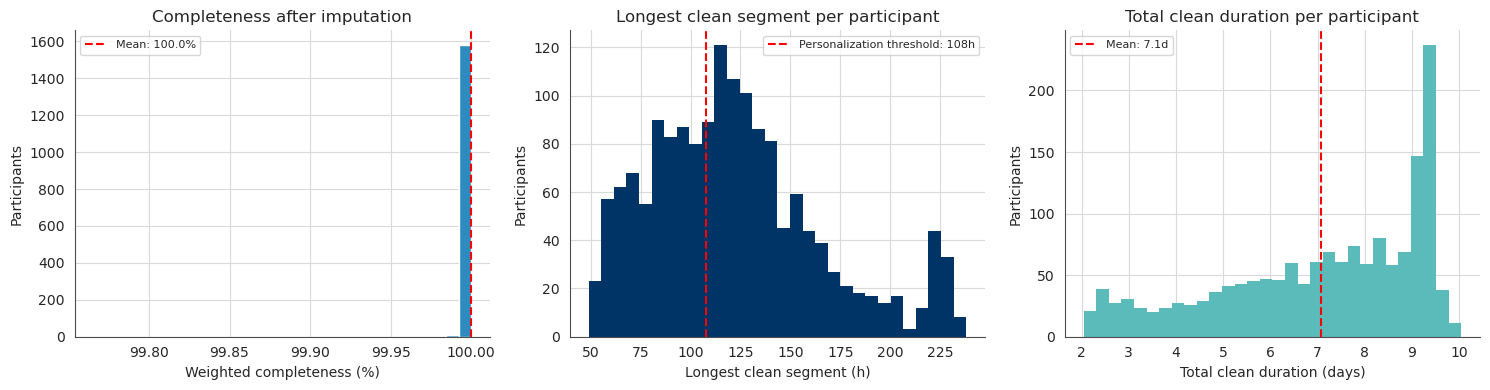

Saved: /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/cohort_post_selection_diagnostics.png
Source: cohort.csv
Columns used: post_weighted_completeness, longest_seg_h, total_clean_dur_h, personalization_eligible
Personalization eligible (longest segment >= 108h): 958/1591
Retained cohort check: 1591 participants, unchanged by this figure.


In [6]:
PERSONALIZATION_H = MIN_DURATION_H  # 108h, same floor used by stage2_diagnostics

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(cohort_df["post_weighted_completeness"] * 100, bins=30,
             color="#2E8BC0", edgecolor="white")
axes[0].axvline(cohort_df["post_weighted_completeness"].mean() * 100, color="red",
                 linestyle="--",
                 label=f"Mean: {cohort_df['post_weighted_completeness'].mean() * 100:.1f}%")
axes[0].set_xlabel("Weighted completeness (%)")
axes[0].set_ylabel("Participants")
axes[0].set_title("Completeness after imputation")
axes[0].legend(fontsize=8)

axes[1].hist(cohort_df["longest_seg_h"], bins=30, color="#003366", edgecolor="none")
axes[1].axvline(PERSONALIZATION_H, color="red", linestyle="--",
                 label=f"Personalization threshold: {PERSONALIZATION_H:.0f}h")
axes[1].set_xlabel("Longest clean segment (h)")
axes[1].set_ylabel("Participants")
axes[1].set_title("Longest clean segment per participant")
axes[1].legend(fontsize=8)

axes[2].hist(cohort_df["total_clean_dur_h"] / 24, bins=30, color="#5BBABA", edgecolor="none")
axes[2].axvline(cohort_df["total_clean_dur_h"].mean() / 24, color="red", linestyle="--",
                 label=f"Mean: {cohort_df['total_clean_dur_h'].mean() / 24:.1f}d")
axes[2].set_xlabel("Total clean duration (days)")
axes[2].set_ylabel("Participants")
axes[2].set_title("Total clean duration per participant")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = FIGURE_DIR / "cohort_post_selection_diagnostics.png"
fig.savefig(out_path, dpi=FIGURE_DPI)
plt.show()

n_pers = int(cohort_df["personalization_eligible"].sum())
print(f"Saved: {out_path}")
print("Source: cohort.csv")
print("Columns used: post_weighted_completeness, longest_seg_h, total_clean_dur_h, "
      "personalization_eligible")
print(f"Personalization eligible (longest segment >= {PERSONALIZATION_H:.0f}h): "
      f"{n_pers}/{len(cohort_df)}")
print(f"Retained cohort check: {len(cohort_df)} participants, unchanged by this figure.")


## Figure: sensitivity to the duration floor

Mirrors `stage2_duration_sensitivity`'s exact duration range (72h to 240h, step 6h) and
candidate filtering logic (`duration_h_trimmed >= dur_h` and at least one valid window
originally recorded), with only the aggregated metric in the second panel swapped from the
`n_valid_windows` sum to the `total_scoreable_anchors` sum.

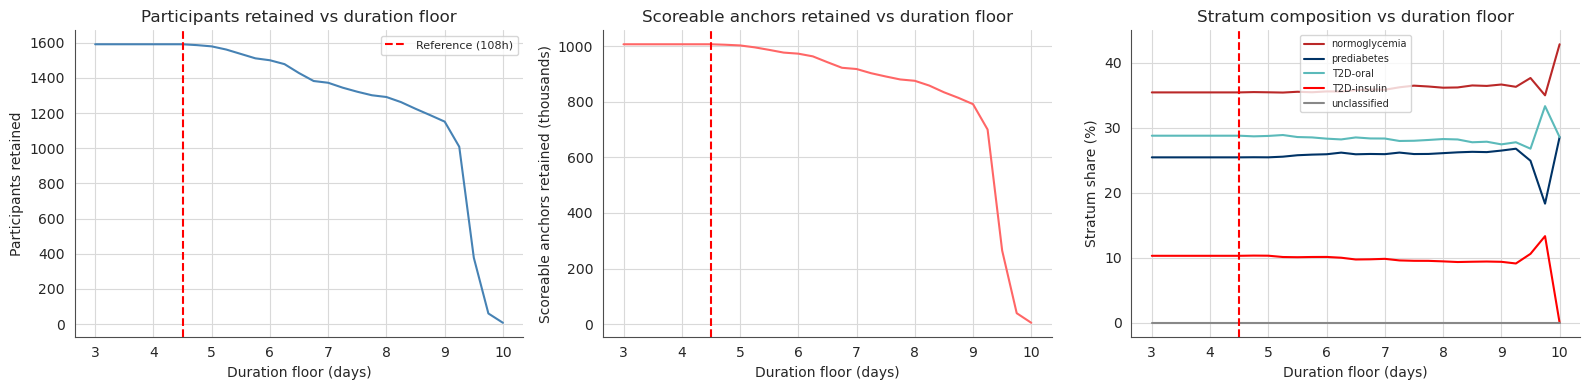

Saved: /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/appendix_duration_floor_sensitivity.png
Source: cohort.csv (duration_h_trimmed, n_valid_windows, stratum), total_scoreable_anchors derived above from segment_stats.csv
Columns used: duration_h_trimmed, n_valid_windows, stratum, total_scoreable_anchors
Retained cohort check: at the reference 108h floor, 1591 participants pass this sweep's mask; cohort.csv has 1591 (the sweep's own >=1 mask is looser than the actual pipeline, so this can differ without meaning the retained cohort changed -- cohort.csv itself is untouched).


In [7]:
DUR_FLOOR_RANGE_H = np.arange(72, 240 + 6, 6)  # matches stage2_duration_sensitivity exactly

dur_sens_rows = []
for dur_h in DUR_FLOOR_RANGE_H:
    mask = (cohort_df["duration_h_trimmed"] >= dur_h) & \
           (cohort_df["n_valid_windows"].fillna(0) >= 1)
    cand = cohort_df[mask]
    n = len(cand)
    row = dict(
        dur_floor_h=float(dur_h),
        dur_floor_d=dur_h / 24,
        n_participants=n,
        total_scoreable_anchors=int(cand["total_scoreable_anchors"].sum()) if n else 0,
    )
    for s in ALL_STRATA:
        row[f"pct_{s}"] = 100 * (cand["stratum"] == s).sum() / n if n else float("nan")
    dur_sens_rows.append(row)

dur_sens_anchors_df = pd.DataFrame(dur_sens_rows)

REF_DUR_D = MIN_DURATION_H / 24

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(dur_sens_anchors_df["dur_floor_d"], dur_sens_anchors_df["n_participants"],
        color="steelblue")
ax.axvline(REF_DUR_D, color="red", linestyle="--", label=f"Reference ({MIN_DURATION_H:.0f}h)")
ax.set_xlabel("Duration floor (days)")
ax.set_ylabel("Participants retained")
ax.set_title("Participants retained vs duration floor")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(dur_sens_anchors_df["dur_floor_d"],
        dur_sens_anchors_df["total_scoreable_anchors"] / 1000, color="#FF6666")
ax.axvline(REF_DUR_D, color="red", linestyle="--")
ax.set_xlabel("Duration floor (days)")
ax.set_ylabel("Scoreable anchors retained (thousands)")
ax.set_title("Scoreable anchors retained vs duration floor")

ax = axes[2]
for s in ALL_STRATA:
    col = f"pct_{s}"
    ax.plot(dur_sens_anchors_df["dur_floor_d"], dur_sens_anchors_df[col],
            label=s, color=STRATUM_COLOR_MAP[s])
ax.axvline(REF_DUR_D, color="red", linestyle="--")
ax.set_xlabel("Duration floor (days)")
ax.set_ylabel("Stratum share (%)")
ax.set_title("Stratum composition vs duration floor")
ax.legend(fontsize=7)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = FIGURE_DIR / "appendix_duration_floor_sensitivity.png"
fig.savefig(out_path, dpi=FIGURE_DPI)
plt.show()

print(f"Saved: {out_path}")
print("Source: cohort.csv (duration_h_trimmed, n_valid_windows, stratum), "
      "total_scoreable_anchors derived above from segment_stats.csv")
print("Columns used: duration_h_trimmed, n_valid_windows, stratum, total_scoreable_anchors")
n_at_ref = int(dur_sens_anchors_df.loc[
    dur_sens_anchors_df["dur_floor_h"] == MIN_DURATION_H, "n_participants"].iloc[0])
print(f"Retained cohort check: at the reference {MIN_DURATION_H:.0f}h floor, "
      f"{n_at_ref} participants pass this sweep's mask; cohort.csv has {len(cohort_df)} "
      f"(the sweep's own >=1 mask is looser than the actual pipeline, so this can differ "
      f"without meaning the retained cohort changed -- cohort.csv itself is untouched).")


## Figure: sensitivity to a minimum-scoreable-anchors threshold

Replaces the old "minimum windows per participant" sweep entirely. The threshold grid is
log-spaced over the observed `total_scoreable_anchors` range printed above (not the old
`MIN_WINDOWS_GRID_BASE` values, which were calibrated to `n_valid_windows`'s coarser 48h
context / 1h stride counting scheme). The duration floor is held fixed at 108h, mirroring
`stage2_joint_sweep`'s per-cell fixed-floor filtering logic.

Minimum-scoreable-anchors threshold grid (log-spaced over the observed range):
  [169, 237, 334, 469, 658, 925]


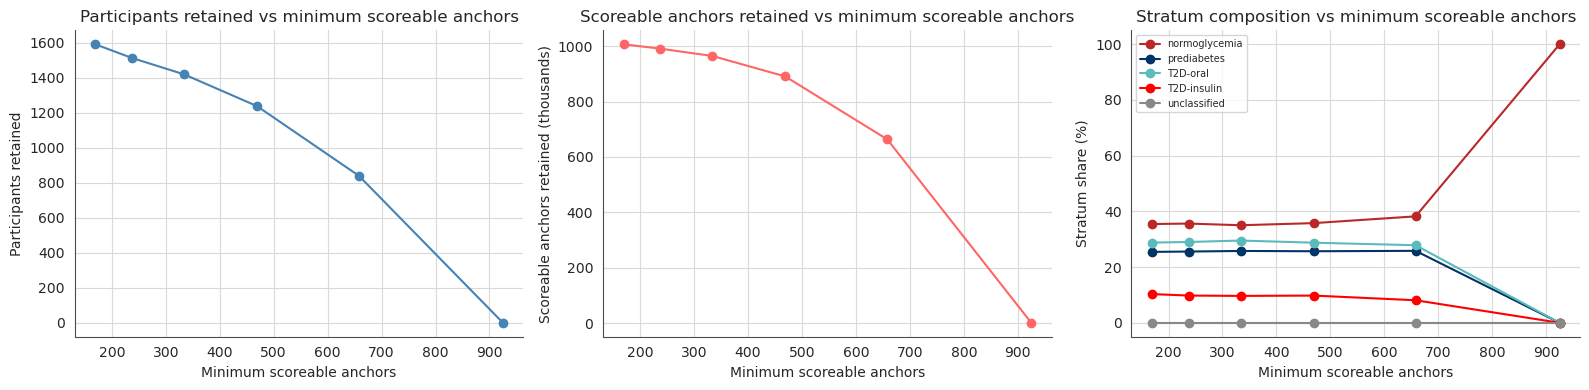

Saved: /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/appendix_min_scoreable_anchors_sensitivity.png
Source: cohort.csv (duration_h_trimmed, stratum), total_scoreable_anchors derived above from segment_stats.csv
Columns used: duration_h_trimmed, stratum, total_scoreable_anchors
Retained cohort check: cohort.csv itself is untouched by this sweep (1591 participants); this only re-derives sensitivity curves over it.


In [8]:
N_ANCHOR_GRID_POINTS = 6

MIN_ANCHORS_GRID = np.unique(np.round(
    np.geomspace(anchor_dist.min(), anchor_dist.max(), N_ANCHOR_GRID_POINTS)
).astype(int))

print("Minimum-scoreable-anchors threshold grid (log-spaced over the observed range):")
print(f"  {MIN_ANCHORS_GRID.tolist()}")

min_anchors_rows = []
fixed_floor_mask = cohort_df["duration_h_trimmed"] >= MIN_DURATION_H
for min_anchors in MIN_ANCHORS_GRID:
    mask = fixed_floor_mask & (cohort_df["total_scoreable_anchors"] >= min_anchors)
    cand = cohort_df[mask]
    n = len(cand)
    row = dict(
        min_anchors_thr=int(min_anchors),
        n_participants=n,
        total_scoreable_anchors=int(cand["total_scoreable_anchors"].sum()) if n else 0,
    )
    for s in ALL_STRATA:
        row[f"pct_{s}"] = 100 * (cand["stratum"] == s).sum() / n if n else float("nan")
    min_anchors_rows.append(row)

min_anchors_sens_df = pd.DataFrame(min_anchors_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(min_anchors_sens_df["min_anchors_thr"], min_anchors_sens_df["n_participants"],
        color="steelblue", marker="o")
ax.set_xlabel("Minimum scoreable anchors")
ax.set_ylabel("Participants retained")
ax.set_title("Participants retained vs minimum scoreable anchors")

ax = axes[1]
ax.plot(min_anchors_sens_df["min_anchors_thr"],
        min_anchors_sens_df["total_scoreable_anchors"] / 1000, color="#FF6666", marker="o")
ax.set_xlabel("Minimum scoreable anchors")
ax.set_ylabel("Scoreable anchors retained (thousands)")
ax.set_title("Scoreable anchors retained vs minimum scoreable anchors")

ax = axes[2]
for s in ALL_STRATA:
    col = f"pct_{s}"
    ax.plot(min_anchors_sens_df["min_anchors_thr"], min_anchors_sens_df[col],
            label=s, color=STRATUM_COLOR_MAP[s], marker="o")
ax.set_xlabel("Minimum scoreable anchors")
ax.set_ylabel("Stratum share (%)")
ax.set_title("Stratum composition vs minimum scoreable anchors")
ax.legend(fontsize=7)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = FIGURE_DIR / "appendix_min_scoreable_anchors_sensitivity.png"
fig.savefig(out_path, dpi=FIGURE_DPI)
plt.show()

print(f"Saved: {out_path}")
print("Source: cohort.csv (duration_h_trimmed, stratum), total_scoreable_anchors derived "
      "above from segment_stats.csv")
print("Columns used: duration_h_trimmed, stratum, total_scoreable_anchors")
print(f"Retained cohort check: cohort.csv itself is untouched by this sweep "
      f"({len(cohort_df)} participants); this only re-derives sensitivity curves over it.")


## Figure: joint sensitivity heatmap (duration floor x minimum scoreable anchors)

Recomputed from scratch against `segment_stats.csv`'s `total_scoreable_anchors` (not
`sweep_results.csv`). Reimplements `stage2_joint_sweep`'s score formula with `SCORE_WEIGHTS
= {"participants": 0.35, "windows": 0.65}`, where "windows" now means scoreable anchors.
The reference cohort's actual thresholds are marked for orientation: the 108h duration
floor, and the loosest minimum-anchors value that still keeps every one of the 1,591
retained participants (their observed `total_scoreable_anchors` minimum).

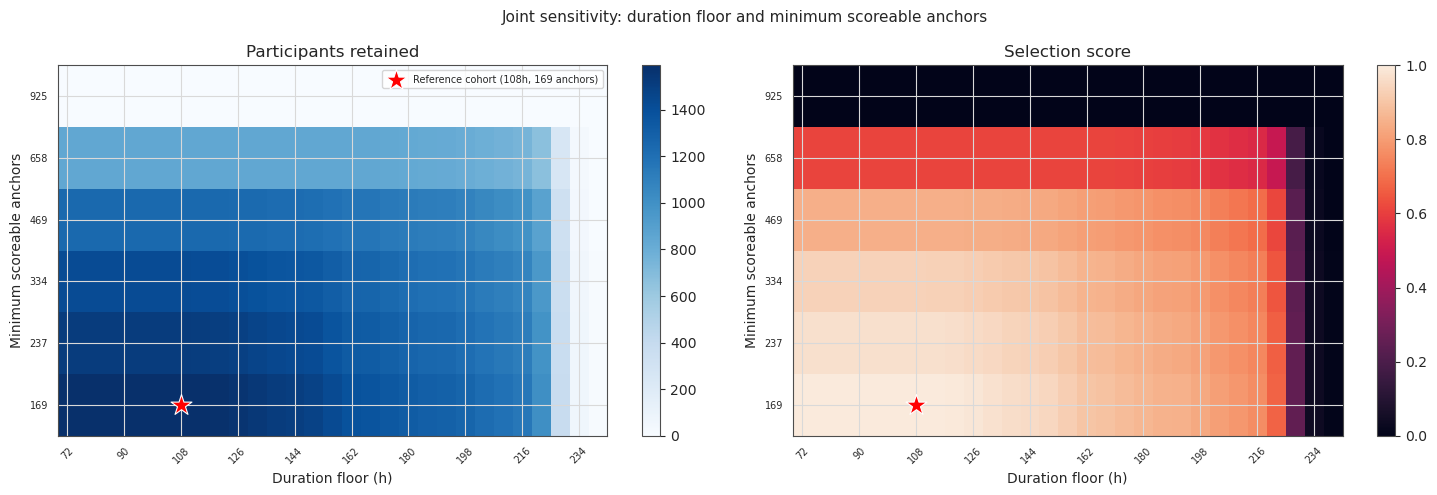

Saved: /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/appendix_joint_sensitivity_heatmap.png
Source: cohort.csv (duration_h_trimmed), total_scoreable_anchors derived above from segment_stats.csv; sweep_results.csv was not reopened
Columns used: duration_h_trimmed, total_scoreable_anchors
Reference cohort marker: duration floor=108h, min scoreable anchors=169 (the retained cohort's own minimum)
Max-score candidate in this grid: dur=72h | min_anchors=169 | N=1591 | anchors=1,007,212 | score=1.0000
Retained cohort check: cohort.csv itself is untouched by this heatmap (1591 participants).


In [9]:
SCORE_WEIGHTS = {"participants": 0.35, "windows": 0.65}  # "windows" now means scoreable anchors

total_participants_pool = len(cohort_df)
total_anchors_pool = int(cohort_df["total_scoreable_anchors"].sum())

joint_rows = []
for dur_h in DUR_FLOOR_RANGE_H:
    dur_mask = cohort_df["duration_h_trimmed"] >= dur_h
    for min_anchors in MIN_ANCHORS_GRID:
        mask = dur_mask & (cohort_df["total_scoreable_anchors"] >= min_anchors)
        cand = cohort_df[mask]
        n = len(cand)
        w = int(cand["total_scoreable_anchors"].sum()) if n else 0
        score = ((n / total_participants_pool) ** SCORE_WEIGHTS["participants"] *
                  (w / max(1, total_anchors_pool)) ** SCORE_WEIGHTS["windows"])
        joint_rows.append(dict(dur_floor_h=float(dur_h), min_anchors_thr=int(min_anchors),
                                n_participants=n, total_scoreable_anchors=w, score=float(score)))

joint_sweep_df = pd.DataFrame(joint_rows)

# Reference thresholds: the actual duration floor, and the loosest minimum-anchors value
# that still retains every participant in the final 1,591-participant cohort.
REF_DUR_H = MIN_DURATION_H
REF_MIN_ANCHORS = int(cohort_df["total_scoreable_anchors"].min())

pivot_n     = joint_sweep_df.pivot(index="min_anchors_thr", columns="dur_floor_h", values="n_participants")
pivot_score = joint_sweep_df.pivot(index="min_anchors_thr", columns="dur_floor_h", values="score")

ref_col_idx = list(pivot_n.columns).index(REF_DUR_H)
ref_row_idx = list(pivot_n.index).index(
    min(pivot_n.index, key=lambda v: abs(v - REF_MIN_ANCHORS))
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im0 = axes[0].imshow(pivot_n.values, aspect="auto", origin="lower", cmap="Blues")
axes[0].scatter([ref_col_idx], [ref_row_idx], marker="*", s=250, color="red",
                 edgecolor="white", linewidth=0.8, zorder=5,
                 label=f"Reference cohort ({REF_DUR_H:.0f}h, {REF_MIN_ANCHORS} anchors)")
axes[0].set_title("Participants retained")
axes[0].legend(fontsize=7, loc="upper right")

im1 = axes[1].imshow(pivot_score.values, aspect="auto", origin="lower")
axes[1].scatter([ref_col_idx], [ref_row_idx], marker="*", s=250, color="red",
                 edgecolor="white", linewidth=0.8, zorder=5)
axes[1].set_title("Selection score")

for ax, im in zip(axes, [im0, im1]):
    ax.set_xticks(range(0, len(pivot_n.columns), max(1, len(pivot_n.columns) // 8)))
    ax.set_xticklabels([f"{v:.0f}" for v in
                         pivot_n.columns[::max(1, len(pivot_n.columns) // 8)]],
                        fontsize=7, rotation=45)
    ax.set_yticks(range(len(pivot_n.index)))
    ax.set_yticklabels(pivot_n.index.tolist(), fontsize=7)
    ax.set_xlabel("Duration floor (h)")
    ax.set_ylabel("Minimum scoreable anchors")
    plt.colorbar(im, ax=ax)

fig.suptitle("Joint sensitivity: duration floor and minimum scoreable anchors", fontsize=11)
fig.tight_layout()

out_path = FIGURE_DIR / "appendix_joint_sensitivity_heatmap.png"
fig.savefig(out_path, dpi=FIGURE_DPI)
plt.show()

best = joint_sweep_df.loc[joint_sweep_df["score"].idxmax()]
print(f"Saved: {out_path}")
print("Source: cohort.csv (duration_h_trimmed), total_scoreable_anchors derived above from "
      "segment_stats.csv; sweep_results.csv was not reopened")
print("Columns used: duration_h_trimmed, total_scoreable_anchors")
print(f"Reference cohort marker: duration floor={REF_DUR_H:.0f}h, "
      f"min scoreable anchors={REF_MIN_ANCHORS} (the retained cohort's own minimum)")
print(f"Max-score candidate in this grid: dur={best['dur_floor_h']:.0f}h | "
      f"min_anchors={int(best['min_anchors_thr'])} | N={int(best['n_participants'])} | "
      f"anchors={int(best['total_scoreable_anchors']):,} | score={best['score']:.4f}")
print(f"Retained cohort check: cohort.csv itself is untouched by this heatmap "
      f"({len(cohort_df)} participants).")


## Summary: retained cohort integrity check

Confirms the retained cohort (participant count and identities) is identical to
`cohort.csv` after every figure above, since nothing in this notebook filters, drops, or
re-derives cohort membership -- only visualizations and sensitivity sweeps over the
already-selected 1,591 participants.

In [10]:
final_ids = set(cohort_df["participant_id"].astype(str))

print(f"Participant count in cohort.csv         : {len(RETAINED_PARTICIPANT_IDS)}")
print(f"Participant count after all figure cells: {len(final_ids)}")
print(f"Identity match (same participant_id set): {final_ids == RETAINED_PARTICIPANT_IDS}")
print(f"Row count of cohort_df at end of notebook: {len(cohort_df)}")
assert final_ids == RETAINED_PARTICIPANT_IDS, "Retained cohort identity changed -- this must never happen"
assert len(cohort_df) == 1591, "Retained cohort count changed -- this must never happen"
print("\nConfirmed: the retained cohort (1,591 participants) is unchanged by this notebook.")


Participant count in cohort.csv         : 1591
Participant count after all figure cells: 1591
Identity match (same participant_id set): True
Row count of cohort_df at end of notebook: 1591

Confirmed: the retained cohort (1,591 participants) is unchanged by this notebook.


## Output files

All figures generated by this notebook, saved under `figures/generated/`.

In [11]:
generated_paths = [
    FIGURE_DIR / "cohort_attrition_funnel.png",
    FIGURE_DIR / "cohort_post_selection_diagnostics.png",
    FIGURE_DIR / "appendix_duration_floor_sensitivity.png",
    FIGURE_DIR / "appendix_min_scoreable_anchors_sensitivity.png",
    FIGURE_DIR / "appendix_joint_sensitivity_heatmap.png",
]

print("Generated figures:")
for p in generated_paths:
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status}] {p}")


Generated figures:
  [OK] /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/cohort_attrition_funnel.png
  [OK] /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/cohort_post_selection_diagnostics.png
  [OK] /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/appendix_duration_floor_sensitivity.png
  [OK] /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/appendix_min_scoreable_anchors_sensitivity.png
  [OK] /home/myriamcharfeddine/CGM/SSM-CGM/figures/generated/appendix_joint_sensitivity_heatmap.png
